# Example: Static forward free-boundary equilibrium calculations (in OpenSTEP)

---

This example notebook demonstrates how to perform a **static forward** free-boundary Grad–Shafranov solve for the **OpenSTEP** spherical tokamak using FreeGSNKE.

### About OpenSTEP
[OpenSTEP](https://github.com/ukaea/OpenSTEP) is an open-access repository developed by the UK Atomic Energy Authority (UKAEA) containing physics and engineering data for the Spherical Tokamak for Energy Production (STEP) prototype power plant.

The machine configuration features:
- **7 active coil circuits** (`p3`, `p4`, `p5`, `p6`, `p9`, `s1`, `s2`), consisting of up-down symmetric coil pairs (14 physical coils discretized into multiple filaments).
- **First wall and divertor contour**: 514 boundary points describing the detailed inner wall and divertor baffles.
- **Reference plasma equilibrium**: A 22.76 MA double-null diverted plasma with $B_0 = 2.4338$ T at $R_0 = 4.7334$ m ($f_{\text{vac}} = R_0 B_0 = 11.52\ \text{T}\cdot\text{m}$), and poloidal beta $\beta_p \approx 1.04$.

In this notebook, we:
1. Build the OpenSTEP machine model from configuration files in `machine_configs/OpenSTEP/`.
2. Inspect the machine geometry (coils and first wall).
3. Apply the reference coil currents shipped with OpenSTEP.
4. Set up the equilibrium grid and plasma profile.
5. Solve the free-boundary equilibrium using FreeGSNKE's Newton–Krylov solver (`NKGSsolver`).
6. Visualise the converged magnetic flux surfaces, separatrix, X-points, and field profiles.


### 1. Import packages

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

from freegsnke import build_machine, equilibrium_update, GSstaticsolver
from freegsnke.jtor_update import ConstrainBetapIp, GeneralPprimeFFprime
from freegs4e.gradshafranov import mu0


### 2. Build the OpenSTEP machine object

We instantiate the machine using `build_machine.tokamak()` pointing to the OpenSTEP description files in `../machine_configs/OpenSTEP/`.


In [2]:
tokamak = build_machine.tokamak(
    active_coils_path="../machine_configs/OpenSTEP/OpenSTEP_active_coils.pickle",
    passive_coils_path="../machine_configs/OpenSTEP/OpenSTEP_passive_coils.pickle",
    limiter_path="../machine_configs/OpenSTEP/OpenSTEP_limiter.pickle",
    wall_path="../machine_configs/OpenSTEP/OpenSTEP_wall.pickle",
)

print("Available coil circuits:", list(tokamak.getCurrents().keys()))
print(f"Wall contour points: {len(tokamak.wall.R)}")


Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.
Magnetic probes --> none provided.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.
Available coil circuits: ['p3', 'p4', 'p5', 'p6', 'p9', 's1', 's2']
Wall contour points: 514


### 3. Visualise the machine geometry

Let us plot the active coils, vacuum vessel / first wall, and limiter.

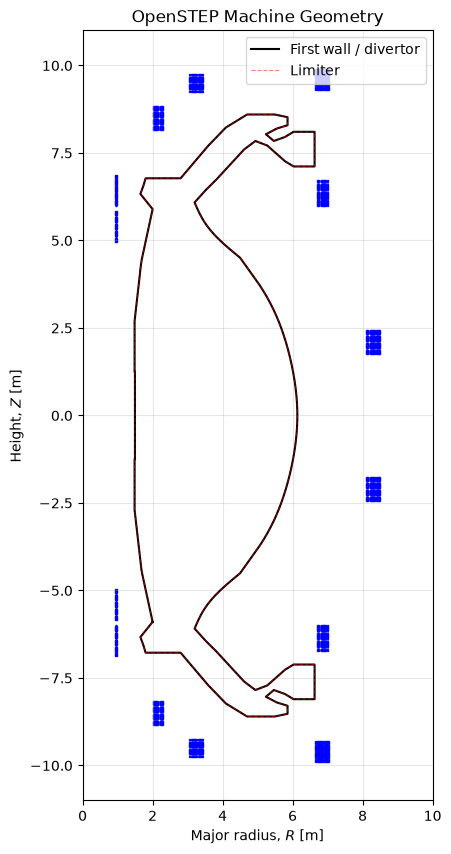

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 10), dpi=100)

tokamak.plot(axis=ax, show=False)
ax.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.5, label='First wall / divertor')
ax.plot(tokamak.limiter.R, tokamak.limiter.Z, 'r--', linewidth=0.8, alpha=0.5, label='Limiter')

ax.set_aspect('equal')
ax.set_xlim(0.0, 10.0)
ax.set_ylim(-11.0, 11.0)
ax.set_xlabel('Major radius, $R$ [m]')
ax.set_ylabel('Height, $Z$ [m]')
ax.set_title('OpenSTEP Machine Geometry')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.show()


### 4. Set shipped coil currents

OpenSTEP ships reference coil currents corresponding to the equilibrium in the free-boundary scenario `STEP_SPP_001_EBCC_freeboundary.nc`. We load these currents from `OpenSTEP_coil_currents.pickle` and apply them to the machine circuits.


In [4]:
with open("../machine_configs/OpenSTEP/OpenSTEP_coil_currents.pickle", "rb") as f:
    shipped_currents = pickle.load(f)

print("Shipped OpenSTEP coil currents:")
for circuit, current in shipped_currents.items():
    tokamak.set_coil_current(coil_label=circuit, current_value=current)
    print(f"  {circuit:4s}: {current / 1e6:10.4f} MA ({current:13.2f} A)")


Shipped OpenSTEP coil currents:
  p3  :    -4.7909 MA (  -4790870.39 A)
  p4  :     5.1555 MA (   5155466.64 A)
  p5  :     2.2547 MA (   2254704.04 A)
  p6  :     5.4589 MA (   5458947.31 A)
  p9  :    -7.8544 MA (  -7854367.89 A)
  s1  :     5.1000 MA (   5100000.00 A)
  s2  :    -2.2746 MA (  -2274646.53 A)


### 5. Instantiate the equilibrium

We define a 2D computational domain spanning $R \in [0.5, 9.0]$ m and $Z \in [-10.0, 10.0]$ m, enclosing the entire plasma domain and wall.
We select a grid resolution of $n_x = 65$ and $n_y = 129$ (both of the form $2^n + 1$).


In [5]:
eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.5,
    Rmax=9.0,
    Zmin=-10.0,
    Zmax=10.0,
    nx=65,
    ny=129,
)
print(f"Equilibrium grid initialized: {eq.nx} x {eq.ny} points, dR = {eq.dR:.4f} m, dZ = {eq.dZ:.4f} m")


Equilibrium grid initialized: 65 x 129 points, dR = 0.1328 m, dZ = 0.1562 m


### 6. Define the plasma profile

We configure the plasma profile using the `ConstrainBetapIp` profile constraint:
- Plasma current: $I_p = 22.76\ \text{MA}$ ($22,760,461\ \text{A}$)
- Vacuum toroidal field: $f_{\text{vac}} = R_0 B_0 = 4.7334 \times 2.4338 \approx 11.52\ \text{T}\cdot\text{m}$
- Poloidal beta: $\beta_p = 1.042$ (matching the reference OpenSTEP equilibrium)


In [6]:
profiles = ConstrainBetapIp(
    eq=eq,
    betap=1.042,
    Ip=22.76e6,
    fvac=11.52,
    alpha_m=1.0,
    alpha_n=1.5,
)
print("Profile initialized: ConstrainBetapIp (Ip = 22.76 MA, betap = 1.042, fvac = 11.52 T*m)")


Profile initialized: ConstrainBetapIp (Ip = 22.76 MA, betap = 1.042, fvac = 11.52 T*m)


### 7. Run the forward static solve

We initialize FreeGSNKE's Newton–Krylov solver (`NKGSsolver`) with 4th-order Grad–Shafranov finite-difference operators (`gs_operator_order=4`).
In forward mode, we call `solver.solve()` with `constrain=None`, which holds the coil currents fixed and solves for the free-boundary plasma equilibrium.


In [7]:
solver = GSstaticsolver.NKGSsolver(eq, gs_operator_order=4)

solver.solve(
    eq=eq,
    profiles=profiles,
    constrain=None,
    target_relative_tolerance=1e-8,
    verbose=True,
)


O-point could not be generated by simply scaling up psi_plasma.
Manual initialization advised.
-----
Forward static solve starting...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Default plasma_psi initialisation and adjustment invoked.
Initial relative error = 1.02e+00
-----
Forward static solve starting...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial guess for plasma_psi failed, trying to scale...
Initial

-----
Newton-Krylov iteration: 19
...number of Krylov vectors used =  17
Update too large, resized.
...relative error =  6.74e-02
-----
-----
Newton-Krylov iteration: 20
...number of Krylov vectors used =  2
Update too large, resized.
...relative error =  5.61e-02
-----


-----
Newton-Krylov iteration: 21
...number of Krylov vectors used =  17
Update too large, resized.
...relative error =  5.74e-02
-----
-----
Newton-Krylov iteration: 22
...number of Krylov vectors used =  17
Update too large, resized.
...relative error =  4.51e-02
-----


-----
Newton-Krylov iteration: 23
...number of Krylov vectors used =  17
Update too large, resized.
Increase in residual, update reduction triggered.
...relative error =  4.81e-02
-----
-----
Newton-Krylov iteration: 24
...number of Krylov vectors used =  2
...relative error =  3.70e-02
-----
-----
Newton-Krylov iteration: 25
...number of Krylov vectors used =  2
Update too large, resized.
...relative error =  3.09e-02
-----
-----
Newton-Krylov iteration: 26
...number of Krylov vectors used =  17
Update too large, resized.
Increase in residual, update reduction triggered.
...relative error =  4.86e-02
-----


-----
Newton-Krylov iteration: 27
...number of Krylov vectors used =  1
...relative error =  3.12e-02
-----
-----
Newton-Krylov iteration: 28
...number of Krylov vectors used =  2
...relative error =  2.52e-02
-----
-----
Newton-Krylov iteration: 29
...number of Krylov vectors used =  17
...relative error =  3.29e-02
-----
-----
Newton-Krylov iteration: 30
...number of Krylov vectors used =  2
...relative error =  2.84e-02
-----


...

-----
Newton-Krylov iteration: 41
...number of Krylov vectors used =  3
Increase in residual, update reduction triggered.
...relative error =  9.73e-03
-----


-----
Newton-Krylov iteration: 42
...number of Krylov vectors used =  2
Increase in residual, update reduction triggered.
...relative error =  4.50e-03
-----
-----
Newton-Krylov iteration: 43
...number of Krylov vectors used =  2
...relative error =  1.42e-04
-----


-----
Newton-Krylov iteration: 44
...number of Krylov vectors used =  2
...relative error =  2.11e-05
-----
-----
Newton-Krylov iteration: 45
...number of Krylov vectors used =  2
...relative error =  1.82e-06
-----


-----
Newton-Krylov iteration: 46
...number of Krylov vectors used =  2
...relative error =  1.58e-08
-----


-----
Newton-Krylov iteration: 47
...number of Krylov vectors used =  2
...relative error =  5.84e-10
-----
Forward static solve SUCCESS. Tolerance 5.84e-10 (vs. requested 1.00e-08) reached in 48/100 iterations.


### 8. Inspect equilibrium properties

Let us print key global quantities of the converged OpenSTEP equilibrium.

In [8]:
print("=== Converged OpenSTEP Equilibrium Parameters ===")
print(f"Plasma Current (Ip):    {eq.plasmaCurrent() / 1e6:.4f} MA")
print(f"Poloidal Beta (betap):  {eq.poloidalBeta():.4f}")
print(f"Magnetic Axis (psi):    {eq.psi_axis:.4f} Wb/2pi")
print(f"Boundary Flux (psi):    {eq.psi_bndry:.4f} Wb/2pi")
print(f"Plasma Volume:          {eq.plasmaVolume():.2f} m^3")


=== Converged OpenSTEP Equilibrium Parameters ===
Plasma Current (Ip):    22.7600 MA
Dicrepancy between psi_func and plasma_psi detected. psi_func has been re-set.


Poloidal Beta (betap):  1.0457
Magnetic Axis (psi):    117.0900 Wb/2pi
Boundary Flux (psi):    84.1387 Wb/2pi
Plasma Volume:          2.33 m^3


### 9. Visualise the converged equilibrium

We plot the 2D poloidal flux surfaces $\psi(R, Z)$, the separatrix / last closed flux surface (LCFS), the magnetic axis, X-points, coils, and first-wall geometry.


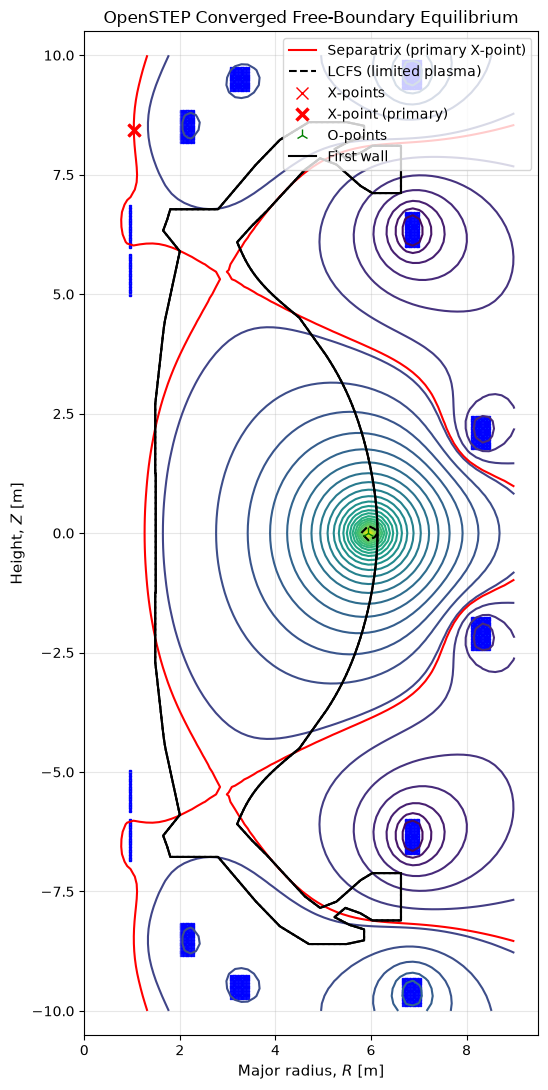

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 11), dpi=100)

# Plot equilibrium contours, separatrix, and limiter
eq.plot(axis=ax, show=False)

# Overlay wall and coils
ax.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.5, label='First wall')
tokamak.plot(axis=ax, show=False)

ax.set_aspect('equal')
ax.set_xlim(0.0, 9.5)
ax.set_ylim(-10.5, 10.5)
ax.set_xlabel('Major radius, $R$ [m]', fontsize=11)
ax.set_ylabel('Height, $Z$ [m]', fontsize=11)
ax.set_title('OpenSTEP Converged Free-Boundary Equilibrium', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


### 10. Midplane profiles and flux distribution

Below we plot the poloidal magnetic flux $\psi$ and toroidal current density $J_\phi$ across the midplane ($Z = 0$).

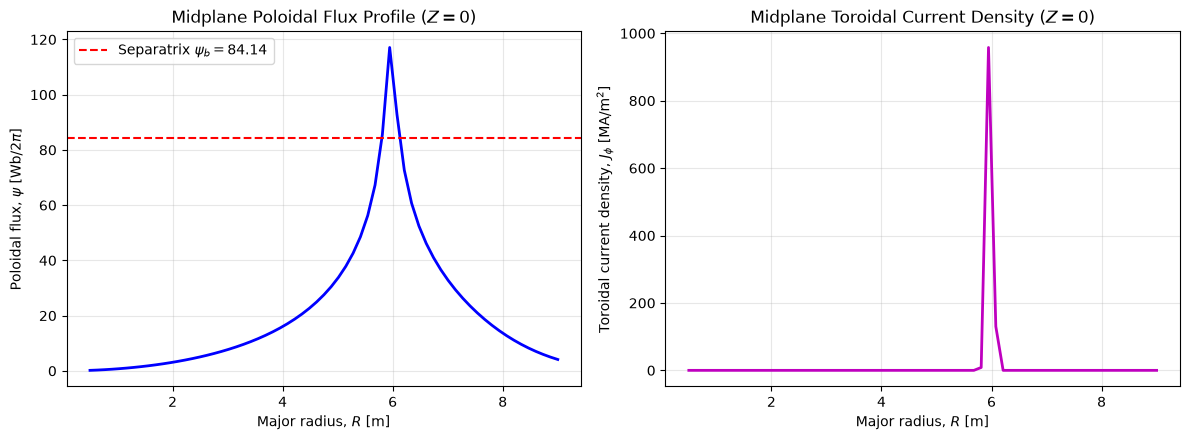

In [10]:
# Find midplane index closest to Z=0
iz_mid = np.argmin(np.abs(eq.Z[0, :]))
R_mid = eq.R[:, iz_mid]
psi_mid = eq.psi()[:, iz_mid]

# Evaluate Jtor on the grid
Jtor = profiles.Jtor(eq.R, eq.Z, eq.psi())
Jtor_mid = Jtor[:, iz_mid]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=100)

ax1.plot(R_mid, psi_mid, 'b-', linewidth=2)
ax1.axhline(eq.psi_bndry, color='r', linestyle='--', label=rf'Separatrix $\psi_b = {eq.psi_bndry:.2f}$')
ax1.set_xlabel('Major radius, $R$ [m]')
ax1.set_ylabel(r'Poloidal flux, $\psi$ [Wb/2$\pi$]')
ax1.set_title('Midplane Poloidal Flux Profile ($Z = 0$)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(R_mid, Jtor_mid / 1e6, 'm-', linewidth=2)
ax2.set_xlabel('Major radius, $R$ [m]')
ax2.set_ylabel(r'Toroidal current density, $J_\phi$ [MA/m$^2$]')
ax2.set_title('Midplane Toroidal Current Density ($Z = 0$)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 11. (Optional) Forward solve using exact OpenSTEP 1D profiles

OpenSTEP also provides exact 1D spline fits for $p'(\psi_N)$ and $FF'(\psi_N)$, pre-extracted into `OpenSTEP_profiles.pickle`.
Below, we demonstrate how `GeneralPprimeFFprime` can be used to solve the equilibrium using these exact profile functions.


In [11]:
with open("../machine_configs/OpenSTEP/OpenSTEP_profiles.pickle", "rb") as f:
    prof_data = pickle.load(f)

# Re-create equilibrium with converged state as initial guess for fast convergence
eq_exact = eq.create_auxiliary_equilibrium()

profiles_exact = GeneralPprimeFFprime(
    eq=eq_exact,
    Ip=prof_data["Ip"],
    fvac=prof_data["fvac"],
    psi_n=prof_data["psi_n"],
    pprime_data=prof_data["pprime"],
    ffprime_data=prof_data["ffprime"],
    Raxis=prof_data["Raxis"],
    Ip_logic=True,
    interpolator="cubic_spline",
)

solver_exact = GSstaticsolver.NKGSsolver(eq_exact, gs_operator_order=4)

solver_exact.solve(
    eq=eq_exact,
    profiles=profiles_exact,
    constrain=None,
    target_relative_tolerance=1e-8,
    verbose=False,
)

print(f"Exact profile solve SUCCESS!")
print(f"Plasma Current: {eq_exact.plasmaCurrent() / 1e6:.4f} MA (target: 22.76 MA)")
print(f"Poloidal Beta:  {eq_exact.poloidalBeta():.4f}")


Forward static solve SUCCESS. Tolerance 2.44e-10 (vs. requested 1.00e-08) reached in 6/100 iterations.
Exact profile solve SUCCESS!
Plasma Current: 22.7605 MA (target: 22.76 MA)
Dicrepancy between psi_func and plasma_psi detected. psi_func has been re-set.


Poloidal Beta:  1.5240


/home/user/projects/freegsnke/feature-openstep/.venv/lib/python3.12/site-packages/freegs4e/jtor.py:116: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(self.pprime, pvals[i], 1.0)
